In [70]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [71]:
df = pd.read_csv("telecom_churn.csv")

In [72]:
print("First 5 Rows:\n")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

First 5 Rows:

   customer_id telecom_partner gender  age              state     city  \
0            1    Reliance Jio      F   25          Karnataka  Kolkata   
1            2    Reliance Jio      F   55            Mizoram   Mumbai   
2            3        Vodafone      F   57  Arunachal Pradesh    Delhi   
3            4            BSNL      M   46         Tamil Nadu  Kolkata   
4            5            BSNL      F   26            Tripura    Delhi   

   pincode date_of_registration  num_dependents  estimated_salary  calls_made  \
0   755597           01-01-2020               4            124962          44   
1   125926           01-01-2020               2            130556          62   
2   423976           01-01-2020               0            148828          49   
3   522841           01-01-2020               1             38722          80   
4   740247           01-01-2020               2             55098          78   

   sms_sent  data_used  churn  
0        45       -36

In [73]:
print("\nDataset Information:\n")
print(df.info())


Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   customer_id           243553 non-null  int64 
 1   telecom_partner       243553 non-null  object
 2   gender                243553 non-null  object
 3   age                   243553 non-null  int64 
 4   state                 243553 non-null  object
 5   city                  243553 non-null  object
 6   pincode               243553 non-null  int64 
 7   date_of_registration  243553 non-null  object
 8   num_dependents        243553 non-null  int64 
 9   estimated_salary      243553 non-null  int64 
 10  calls_made            243553 non-null  int64 
 11  sms_sent              243553 non-null  int64 
 12  data_used             243553 non-null  int64 
 13  churn                 243553 non-null  int64 
dtypes: int64(9), object(5)
memory usage: 26.0+ MB

In [74]:
print("\nMissing Values:\n")
print(df.isnull().sum())


Missing Values:

customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64


In [75]:
print("\nStatistical Summary:\n")
print(df.describe())


Statistical Summary:

         customer_id            age        pincode  num_dependents  \
count  243553.000000  243553.000000  243553.000000   243553.000000   
mean   121777.000000      46.077609  549501.270541        1.997500   
std     70307.839393      16.444029  259808.860574        1.414941   
min         1.000000      18.000000  100006.000000        0.000000   
25%     60889.000000      32.000000  324586.000000        1.000000   
50%    121777.000000      46.000000  548112.000000        2.000000   
75%    182665.000000      60.000000  774994.000000        3.000000   
max    243553.000000      74.000000  999987.000000        4.000000   

       estimated_salary     calls_made       sms_sent      data_used  \
count     243553.000000  243553.000000  243553.000000  243553.000000   
mean       85021.137839      49.010548      23.945404    4993.186025   
std        37508.963233      29.453556      14.733575    2942.019547   
min        20000.000000     -10.000000      -5.000000    -

In [76]:
print("\nChurn Values:")
print(df["churn"].unique())


Churn Values:
[0 1]


In [77]:
df.drop(
    "customer_id",
    axis=1,
    inplace=True
)

In [78]:
df["date_of_registration"] = pd.to_datetime(
    df["date_of_registration"],
    dayfirst=True
)

In [79]:
df["registration_year"] = (
    df["date_of_registration"].dt.year
)

df["registration_month"] = (
    df["date_of_registration"].dt.month
)

In [80]:
df.drop(
    "date_of_registration",
    axis=1,
    inplace=True
)

In [81]:
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

print("\nCategorical Columns:")
print(categorical_columns)

le = LabelEncoder()

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])


Categorical Columns:
Index(['telecom_partner', 'gender', 'state', 'city'], dtype='object')


In [82]:
print("\nProcessed Dataset:\n")
print(df.head())


Processed Dataset:

   telecom_partner  gender  age  state  city  pincode  num_dependents  \
0                2       0   25     10     4   755597               4   
1                2       0   55     16     5   125926               2   
2                3       0   57      1     2   423976               0   
3                1       1   46     22     4   522841               1   
4                1       0   26     24     2   740247               2   

   estimated_salary  calls_made  sms_sent  data_used  churn  \
0            124962          44        45       -361      0   
1            130556          62        39       5973      0   
2            148828          49        24        193      1   
3             38722          80        25       9377      1   
4             55098          78        15       1393      0   

   registration_year  registration_month  
0               2020                   1  
1               2020                   1  
2               2020            

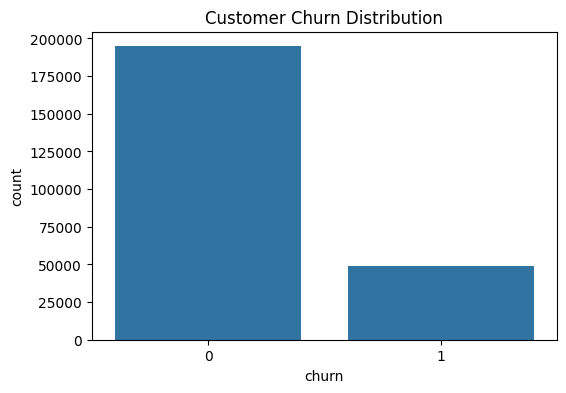

In [83]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="churn",
    data=df
)

plt.title("Customer Churn Distribution")

plt.show()

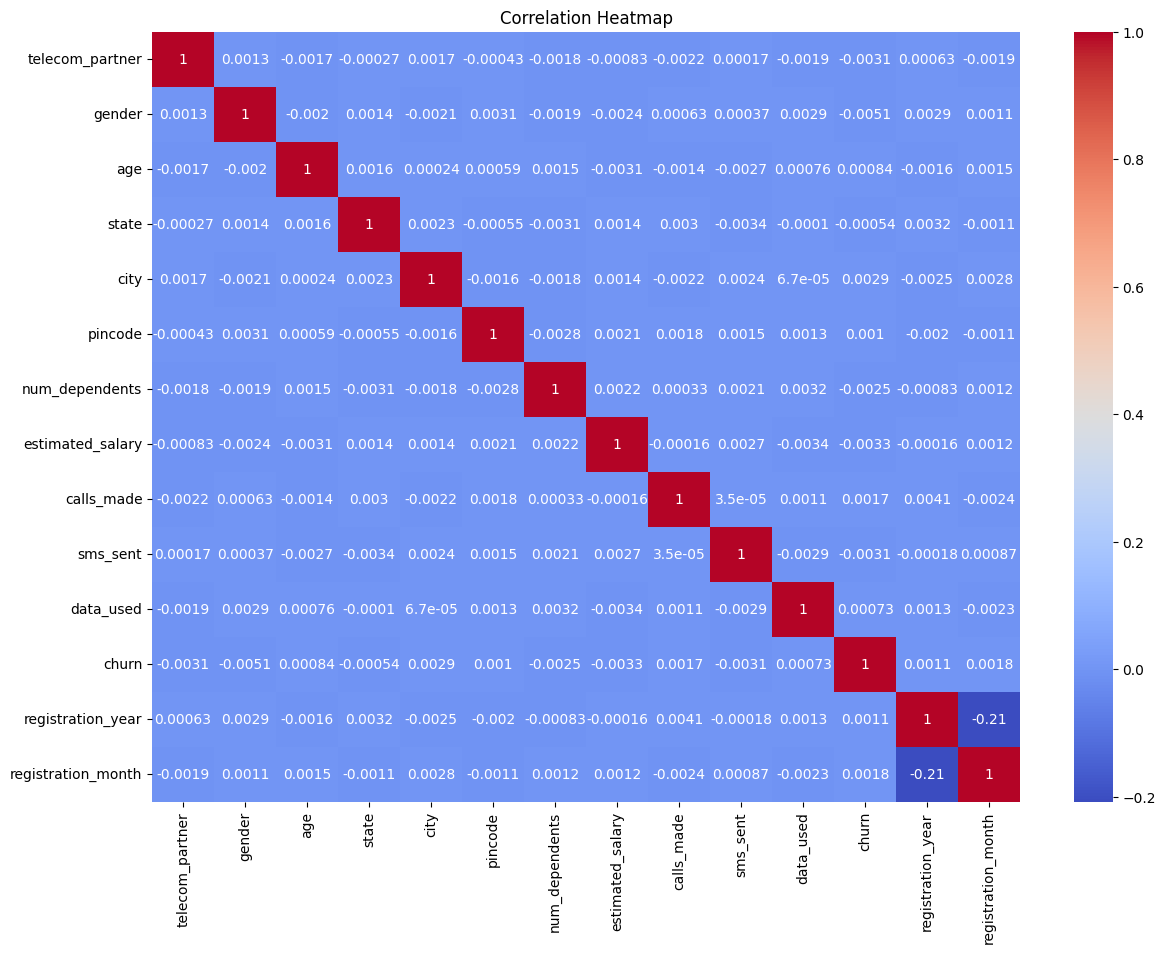

In [84]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

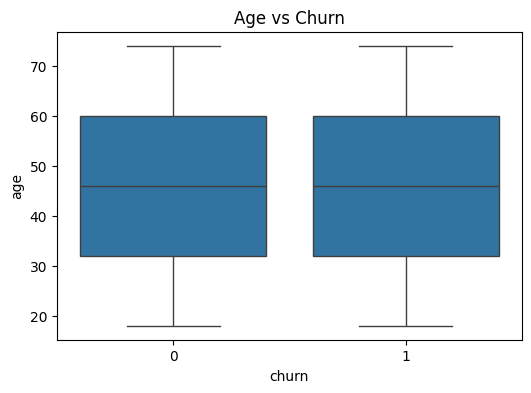

In [85]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="churn",
    y="age",
    data=df
)

plt.title("Age vs Churn")

plt.show()

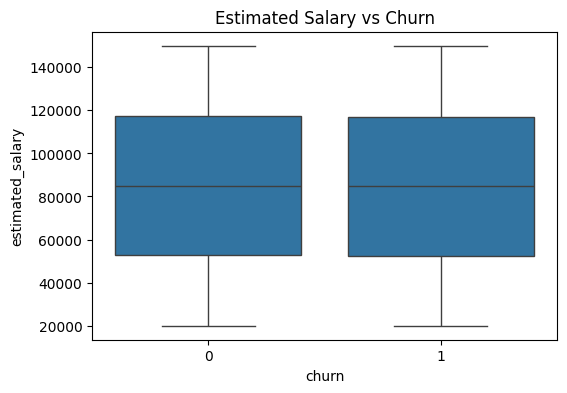

In [86]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="churn",
    y="estimated_salary",
    data=df
)

plt.title("Estimated Salary vs Churn")

plt.show()

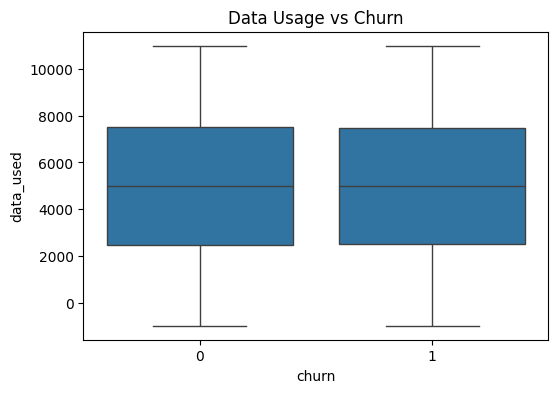

In [87]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="churn",
    y="data_used",
    data=df
)

plt.title("Data Usage vs Churn")

plt.show()

In [88]:
X = df.drop("churn", axis=1)

y = df["churn"]

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [90]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [91]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("\nBefore SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())


Before SMOTE:
churn
0    155780
1     39062
Name: count, dtype: int64

After SMOTE:
churn
0    155780
1    155780
Name: count, dtype: int64


In [92]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

In [93]:
xgb.fit(
    X_train_smote,
    y_train_smote
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [94]:
y_pred = xgb.predict(X_test_scaled)

In [95]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nModel Accuracy:")
print(accuracy)


Model Accuracy:
0.7995319332388988


In [96]:
print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)


Classification Report:

              precision    recall  f1-score   support

           0       0.80      1.00      0.89     38946
           1       0.00      0.00      0.00      9765

    accuracy                           0.80     48711
   macro avg       0.40      0.50      0.44     48711
weighted avg       0.64      0.80      0.71     48711



In [97]:
roc_score = roc_auc_score(
    y_test,
    y_pred
)

print("\nROC-AUC Score:")
print(roc_score)


ROC-AUC Score:
0.5


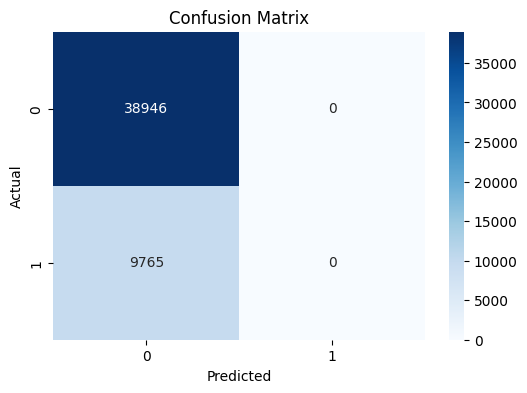

In [98]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [99]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:\n")
print(feature_importance)


Feature Importance:

               Feature  Importance
4                 city    0.269553
6       num_dependents    0.245976
0      telecom_partner    0.173991
12  registration_month    0.158980
11   registration_year    0.077237
3                state    0.034253
2                  age    0.011763
9             sms_sent    0.008997
8           calls_made    0.004955
7     estimated_salary    0.004470
5              pincode    0.003778
10           data_used    0.003470
1               gender    0.002577


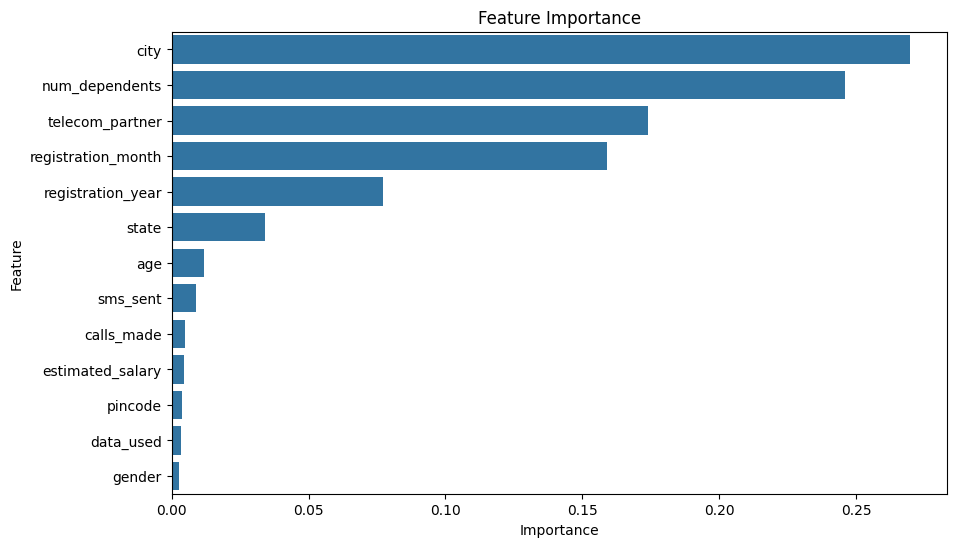

In [100]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

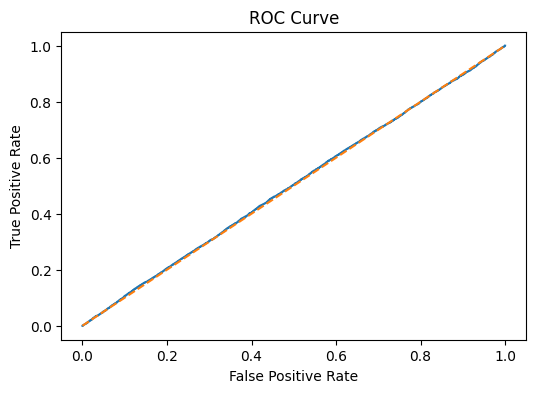

In [101]:
y_prob = xgb.predict_proba(
    X_test_scaled
)[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()